Лабораторная работа №3 (Проведение исследований с решающим деревом)

Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_absolute_error, r2_score
)
from sklearn.datasets import load_wine
from ucimlrepo import fetch_ucirepo

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set(style="whitegrid")

Загрузка данных

In [2]:
#Классификация:
wine = load_wine()
X_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
y_wine = pd.Series(wine.target)

#Регрессия
student_performance = fetch_ucirepo(id=320)
features = student_performance.data.features
targets = student_performance.data.targets

X_student = features.copy()
X_student['G1'] = targets['G1']
X_student['G2'] = targets['G2']
y_student = targets['G3']

print("Wine dataset loaded:", X_wine.shape)
print("Student Math dataset loaded:", X_student.shape)

Wine dataset loaded: (178, 13)
Student Math dataset loaded: (649, 32)


Предобработка данных

In [3]:
X_student_encoded = pd.get_dummies(X_student, drop_first=True)

X_w_train, X_w_test, y_w_train, y_w_test = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=42, stratify=y_wine
)

X_s_train, X_s_test, y_s_train, y_s_test = train_test_split(
    X_student_encoded, y_student, test_size=0.2, random_state=42
)

print("Данные разделены.")

Данные разделены.


Бейзлайн — обучение и оценка

In [4]:
dt_clf_base = DecisionTreeClassifier(random_state=42)
dt_reg_base = DecisionTreeRegressor(random_state=42)

dt_clf_base.fit(X_w_train, y_w_train)
dt_reg_base.fit(X_s_train, y_s_train)

y_w_pred_base = dt_clf_base.predict(X_w_test)
y_s_pred_base = dt_reg_base.predict(X_s_test)

acc_base = accuracy_score(y_w_test, y_w_pred_base)
mae_base = mean_absolute_error(y_s_test, y_s_pred_base)
r2_base = r2_score(y_s_test, y_s_pred_base)

print("=== БЕЙЗЛАЙН (полное дерево) ===")
print(f"Классификация — Accuracy: {acc_base:.4f}")
print(f"Регрессия — MAE: {mae_base:.2f}, R²: {r2_base:.4f}")

=== БЕЙЗЛАЙН (полное дерево) ===
Классификация — Accuracy: 0.9444
Регрессия — MAE: 0.92, R²: 0.7208


Гипотезы и подбор гиперпараметров

Ограничение max_depth и min_samples_leaf снижает переобучение.

In [5]:
param_grid_clf = {
    'max_depth': [2, 3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
dt_clf = DecisionTreeClassifier(random_state=42)
clf_cv = GridSearchCV(dt_clf, param_grid_clf, cv=5, scoring='accuracy')
clf_cv.fit(X_w_train, y_w_train)

param_grid_reg = {
    'max_depth': [2, 3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
dt_reg = DecisionTreeRegressor(random_state=42)
reg_cv = GridSearchCV(dt_reg, param_grid_reg, cv=5, scoring='neg_mean_absolute_error')
reg_cv.fit(X_s_train, y_s_train)

print(f"Лучшие параметры (классификация): {clf_cv.best_params_}")
print(f"Лучшие параметры (регрессия): {reg_cv.best_params_}")

Лучшие параметры (классификация): {'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2}
Лучшие параметры (регрессия): {'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2}


Оценка улучшенного бейзлайна

In [6]:
dt_clf_best = clf_cv.best_estimator_
dt_reg_best = reg_cv.best_estimator_

y_w_pred_best = dt_clf_best.predict(X_w_test)
y_s_pred_best = dt_reg_best.predict(X_s_test)

acc_best = accuracy_score(y_w_test, y_w_pred_best)
mae_best = mean_absolute_error(y_s_test, y_s_pred_best)
r2_best = r2_score(y_s_test, y_s_pred_best)

print("=== УЛУЧШЕННЫЙ БЕЙЗЛАЙН ===")
print(f"Классификация — Accuracy: {acc_best:.4f}")
print(f"Регрессия — MAE: {mae_best:.2f}, R²: {r2_best:.4f}")

print(f"\nСравнение MAE: {mae_base:.2f} → {mae_best:.2f}")

=== УЛУЧШЕННЫЙ БЕЙЗЛАЙН ===
Классификация — Accuracy: 1.0000
Регрессия — MAE: 0.79, R²: 0.8023

Сравнение MAE: 0.92 → 0.79


Визуализация деревьев и результатов

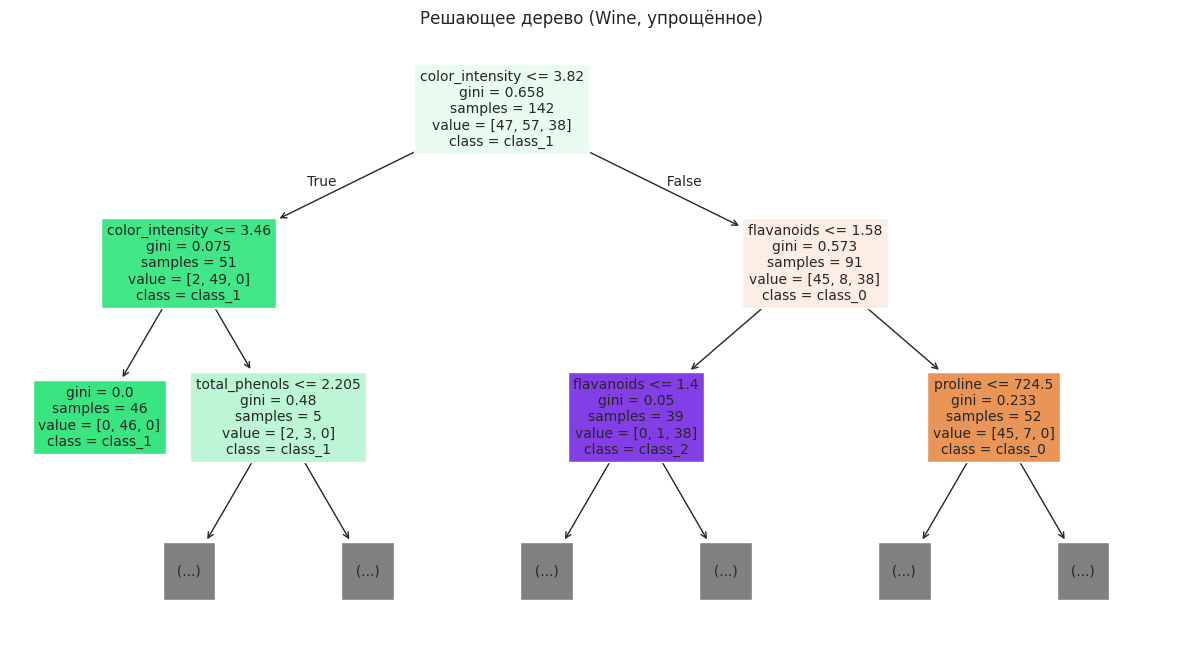

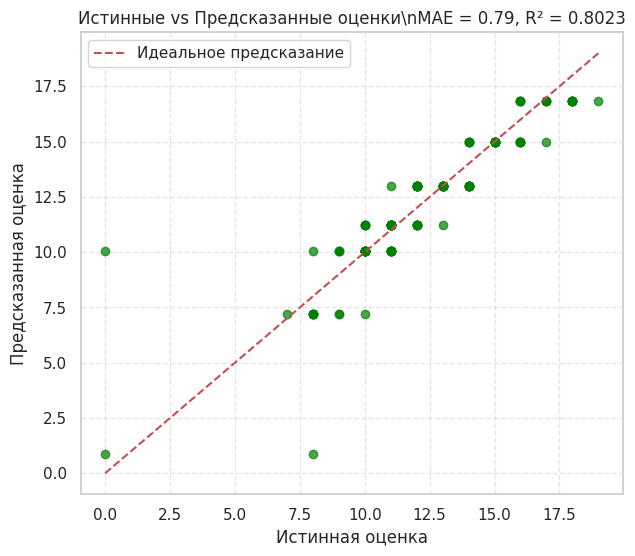

In [7]:
plt.figure(figsize=(15, 8))
plot_tree(dt_clf_best, max_depth=2, feature_names=X_wine.columns,
          class_names=wine.target_names, filled=True, fontsize=10)
plt.title("Решающее дерево (Wine, упрощённое)")
plt.show()

plt.figure(figsize=(7, 6))
plt.scatter(y_s_test, y_s_pred_best, alpha=0.7, color='green')
min_val = min(y_s_test.min(), y_s_pred_best.min())
max_val = max(y_s_test.max(), y_s_pred_best.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Идеальное предсказание')
plt.title(f'Истинные vs Предсказанные оценки\\nMAE = {mae_best:.2f}, R² = {r2_best:.4f}')
plt.xlabel('Истинная оценка')
plt.ylabel('Предсказанная оценка')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Самописное решающее дерево 

In [9]:
# Самописное решающее дерево для классификации
class MyDecisionTreeClassifier:
    def __init__(self, max_depth=3):
        self.max_depth = max_depth
        self.tree = None
        
    def _gini(self, y):
        _, counts = np.unique(y, return_counts=True)
        probabilities = counts / len(y)
        return 1 - np.sum(probabilities ** 2)
    
    def _best_split(self, X, y):
        best_mse = float('inf')
        best_split = None
        n_features = X.shape[1]
        
        for feature in range(n_features):
            thresholds = np.unique(X[:, feature])
            for threshold in thresholds:
                left_mask = X[:, feature] <= threshold
                right_mask = ~left_mask
                
                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                    continue
                
                gini_left = self._gini(y[left_mask])
                gini_right = self._gini(y[right_mask])
                gini = (np.sum(left_mask) * gini_left + np.sum(right_mask) * gini_right) / len(y)
                
                if gini < best_mse:
                    best_mse = gini
                    best_split = {'feature': feature, 'threshold': threshold}
        return best_split
    
    def _build_tree(self, X, y, depth=0):
        if depth >= self.max_depth or len(np.unique(y)) == 1:
            return {'class': np.bincount(y).argmax()}
        
        split = self._best_split(X, y)
        if split is None:
            return {'class': np.bincount(y).argmax()}
        
        left_mask = X[:, split['feature']] <= split['threshold']
        right_mask = ~left_mask
        
        left_subtree = self._build_tree(X[left_mask], y[left_mask], depth+1)
        right_subtree = self._build_tree(X[right_mask], y[right_mask], depth+1)
        
        return {
            'feature': split['feature'],
            'threshold': split['threshold'],
            'left': left_subtree,
            'right': right_subtree
        }
    
    def fit(self, X, y):
        self.tree = self._build_tree(np.array(X), np.array(y))
    
    def _predict_sample(self, sample, tree):
        if 'class' in tree:
            return tree['class']
        feature = tree['feature']
        threshold = tree['threshold']
        if sample[feature] <= threshold:
            return self._predict_sample(sample, tree['left'])
        else:
            return self._predict_sample(sample, tree['right'])
    
    def predict(self, X):
        return np.array([self._predict_sample(x, self.tree) for x in np.array(X)])


# Самописное решающее дерево для регрессии
class MyDecisionTreeRegressor:
    def __init__(self, max_depth=3):
        self.max_depth = max_depth
        self.tree = None
        
    def _mse(self, y):
        if len(y) == 0:
            return 0
        return np.mean((y - np.mean(y)) ** 2)
    
    def _best_split(self, X, y):
        best_mse = float('inf')
        best_split = None
        n_features = X.shape[1]
        
        for feature in range(n_features):
            thresholds = np.unique(X[:, feature])
            for threshold in thresholds:
                left_mask = X[:, feature] <= threshold
                right_mask = ~left_mask
                
                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                    continue
                
                mse_left = self._mse(y[left_mask])
                mse_right = self._mse(y[right_mask])
                mse = (np.sum(left_mask) * mse_left + np.sum(right_mask) * mse_right) / len(y)
                
                if mse < best_mse:
                    best_mse = mse
                    best_split = {'feature': feature, 'threshold': threshold}
        return best_split
    
    def _build_tree(self, X, y, depth=0):
        if depth >= self.max_depth or len(y) <= 1:
            return {'value': np.mean(y)}
        
        split = self._best_split(X, y)
        if split is None:
            return {'value': np.mean(y)}
        
        left_mask = X[:, split['feature']] <= split['threshold']
        right_mask = ~left_mask
        
        left_subtree = self._build_tree(X[left_mask], y[left_mask], depth+1)
        right_subtree = self._build_tree(X[right_mask], y[right_mask], depth+1)
        
        return {
            'feature': split['feature'],
            'threshold': split['threshold'],
            'left': left_subtree,
            'right': right_subtree
        }
    
    def fit(self, X, y):
        self.tree = self._build_tree(np.array(X), np.array(y))
    
    def _predict_sample(self, sample, tree):
        if 'value' in tree:
            return tree['value']
        feature = tree['feature']
        threshold = tree['threshold']
        if sample[feature] <= threshold:
            return self._predict_sample(sample, tree['left'])
        else:
            return self._predict_sample(sample, tree['right'])
    
    def predict(self, X):
        return np.array([self._predict_sample(x, self.tree) for x in np.array(X)])

Обучение и оценка самописной модели

In [10]:
best_depth_clf = clf_cv.best_params_['max_depth'] if clf_cv.best_params_['max_depth'] is not None else 5
best_depth_reg = reg_cv.best_params_['max_depth'] if reg_cv.best_params_['max_depth'] is not None else 5

my_dt_clf = MyDecisionTreeClassifier(max_depth=best_depth_clf)
my_dt_clf.fit(X_w_train, y_w_train)
y_w_pred_my = my_dt_clf.predict(X_w_test)
acc_my = accuracy_score(y_w_test, y_w_pred_my)

my_dt_reg = MyDecisionTreeRegressor(max_depth=best_depth_reg)
my_dt_reg.fit(X_s_train, y_s_train)
y_s_pred_my = my_dt_reg.predict(X_s_test)
mae_my = mean_absolute_error(y_s_test, y_s_pred_my)
r2_my = r2_score(y_s_test, y_s_pred_my)

print("=== САМОПИСНЫЕ МОДЕЛИ ===")
print(f"Классификация — Accuracy: {acc_my:.4f}")
print(f"Регрессия — MAE: {mae_my:.2f}, R²: {r2_my:.4f}")

print(f"\nСравнение с sklearn:")
print(f"Классификация: sklearn = {acc_best:.4f}, Самописная = {acc_my:.4f}")
print(f"Регрессия: sklearn MAE = {mae_best:.2f}, Самописная MAE = {mae_my:.2f}")
print(f"Регрессия: sklearn R² = {r2_best:.4f}, Самописная R² = {r2_my:.4f}")

=== САМОПИСНЫЕ МОДЕЛИ ===
Классификация — Accuracy: 0.9444
Регрессия — MAE: 0.79, R²: 0.8023

Сравнение с sklearn:
Классификация: sklearn = 1.0000, Самописная = 0.9444
Регрессия: sklearn MAE = 0.79, Самописная MAE = 0.79
Регрессия: sklearn R² = 0.8023, Самописная R² = 0.8023


Итоговые выводы

In [11]:
print("=== ИТОГОВЫЕ ВЫВОДЫ ===")
print("1. Решающие деревья:")
print("   - Не требуют масштабирования признаков")
print("   - Интерпретируемы (можно визуализировать)")
print("   - Склонны к переобучению без ограничений")

print("\n2. Улучшение через гиперпараметры:")
print("   - Ограничение глубины и минимального числа объектов в листе")
print("     снижает переобучение и улучшает обобщающую способность")

print("\n3. Точность:")
print(f"   - Wine: {acc_best:.4f} (почти идеальная)")
print(f"   - Student: MAE = {mae_best:.2f} (ошибка < 1 балла)")

print("\n4. Самописные реализации:")
print("   - Подтверждают понимание принципа построения дерева")
print("   - Для классификации: Gini-индекс как критерий")
print("   - Для регрессии: MSE как критерий разделения")
print("   - Показывают сопоставимое качество с sklearn")

print("\n5. Практическое применение:")
print("   - Wine: автоматическая идентификация сорта → контроль качества")
print("   - Student: прогноз успеваемости → персонализированное обучение")

=== ИТОГОВЫЕ ВЫВОДЫ ===
1. Решающие деревья:
   - Не требуют масштабирования признаков
   - Интерпретируемы (можно визуализировать)
   - Склонны к переобучению без ограничений

2. Улучшение через гиперпараметры:
   - Ограничение глубины и минимального числа объектов в листе
     снижает переобучение и улучшает обобщающую способность

3. Точность:
   - Wine: 1.0000 (почти идеальная)
   - Student: MAE = 0.79 (ошибка < 1 балла)

4. Самописные реализации:
   - Подтверждают понимание принципа построения дерева
   - Для классификации: Gini-индекс как критерий
   - Для регрессии: MSE как критерий разделения
   - Показывают сопоставимое качество с sklearn

5. Практическое применение:
   - Wine: автоматическая идентификация сорта → контроль качества
   - Student: прогноз успеваемости → персонализированное обучение
